In [1]:
from pathlib import Path
import json
import pandas as pd

RUNS_ROOT = Path("/home/dgu/fin/01_15_new_qlib/runs")
files = sorted(RUNS_ROOT.glob("*/specs/stage4_summary.json"))
print("found:", len(files))

found: 146


In [2]:
from pathlib import Path
import json
import pandas as pd

RUNS_ROOT = Path("/home/dgu/fin/01_15_new_qlib/runs")
files = sorted(RUNS_ROOT.glob("*/specs/stage4_summary.json"))
print("found:", len(files))

def load_run_qlib_meta(run_dir: Path) -> dict:
    """runs/<run_id>/run_config.json 에서 universe(us/cn) 메타를 읽는다."""
    cfg_path = run_dir / "run_config.json"
    if not cfg_path.exists():
        return {}
    try:
        with open(cfg_path, "r", encoding="utf-8") as f:
            cfg = json.load(f)
        qlib_cfg = ((cfg or {}).get("config", {}) or {}).get("qlib", {}) or {}
        pipeline_cfg = ((cfg or {}).get("config", {}) or {}).get("pipeline_control", {}) or {}
        region = qlib_cfg.get("region")
        return {
            "universe": region,  # "cn" / "us"
            "region": region,
            "qlib_market": qlib_cfg.get("qlib_market"),
            "provider_uri": qlib_cfg.get("provider_uri"),
            "benchmark_code": qlib_cfg.get("benchmark"),
            "enable_stage2": pipeline_cfg.get("enable_stage2"),
            "enable_stage3": pipeline_cfg.get("enable_stage3"),
        }
    except Exception as e:
        print("warn: failed to read run_config:", cfg_path, e)
        return {}

def iter_outer_roots(j: dict):
    """
    stage4_summary 최상단이 {"outer_iter_1": {...}, "outer_iter_2": {...}} 처럼
    여러 outer_iter가 있을 수 있어서 모두 yield.
    단일 dict만 있는 경우에도 대응.
    """
    if not isinstance(j, dict):
        return
    # outer_iter_* 키가 있으면 그걸 전부
    outer_keys = [k for k in j.keys() if isinstance(k, str) and k.startswith("outer_iter_")]
    if outer_keys:
        for k in sorted(outer_keys):
            if isinstance(j.get(k), dict):
                yield k, j[k]
    else:
        # 그냥 root dict인 경우
        yield "root", j

rows = []

for p in files:
    run_dir = p.parents[1]  # runs/<run_id>/specs/stage4_summary.json
    run_id = run_dir.name
    run_meta = load_run_qlib_meta(run_dir)
    try:
        with open(p, "r", encoding="utf-8") as f:
            j = json.load(f)

        for outer_key, root in iter_outer_roots(j):
            base = {
                "run_id": run_id,
                "outer_iter": outer_key,
                **run_meta,
                "hypothesis_id": root.get("hypothesis_id"),
                "backtest_mode": root.get("backtest_mode"),
                "horizon_days": root.get("horizon_days"),
                "in_sample_period": root.get("in_sample_period"),
                "out_sample_period": root.get("out_sample_period"),
            }

            for combo in root.get("all_combinations", []) or []:
                combo_idx = combo.get("combo_idx")

                # (A) optuna 결과 = combo.outsample.excess_return_with_cost
                ex_optuna = (combo.get("outsample", {}) or {}).get("excess_return_with_cost", None)
                rows.append({
                    **base,
                    "combo_idx": combo_idx,
                    "mode": "optuna",
                    "threshold_q": None,  # fixed만 존재
                    "optimal_thresholds": combo.get("optimal_thresholds", None),  # optuna에서 의미있음(있으면)
                    "outsample_excess_return_with_cost": ex_optuna,  # dict 그대로
                })

                # (B) fixed 결과 = combo.fixed_modes[fixed_qXX].outsample.excess_return_with_cost
                fixed_modes = combo.get("fixed_modes", {}) or {}
                for mode_name, mode_data in fixed_modes.items():
                    ex_fixed = (mode_data.get("outsample", {}) or {}).get("excess_return_with_cost", None)
                    rows.append({
                        **base,
                        "combo_idx": combo_idx,
                        "mode": mode_name,  # fixed_q90, fixed_q95 등
                        "threshold_q": mode_data.get("threshold_q", None),
                        "optimal_thresholds": None,  # fixed에는 보통 없음
                        "outsample_excess_return_with_cost": ex_fixed,  # dict 그대로
                    })

    except Exception as e:
        print("fail:", p, e)

df_raw = pd.DataFrame(rows)
df_raw.head()


found: 146
fail: /home/dgu/fin/01_15_new_qlib/runs/20260120_201247/specs/stage4_summary.json Expecting ',' delimiter: line 30 column 57 (char 1393)


,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,optimal_thresholds,outsample_excess_return_with_cost,universe,region,qlib_market,provider_uri,benchmark_code,enable_stage2,enable_stage3
0,20260122_100355,root,BH_MR_PanicSelling_3D_v1,qlib,3.0,2023-01-01 ~ 2024-12-31,2025-01-01 ~ 2025-12-31,1,optuna,NaN,"{'volume_surge_zscore': 0.71866277978636, 'liq...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260122_100355,root,BH_MR_PanicSelling_3D_v1,qlib,3.0,2023-01-01 ~ 2024-12-31,2025-01-01 ~ 2025-12-31,2,optuna,NaN,"{'volume_surge_zscore': 0.8614988717085303, 'l...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260122_100355,root,BH_MR_PanicSelling_3D_v1,qlib,3.0,2023-01-01 ~ 2024-12-31,2025-01-01 ~ 2025-12-31,3,optuna,NaN,"{'volume_surge_zscore': 0.6531239780871886, 'l...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260122_100355,root,BH_MR_PanicSelling_3D_v1,qlib,3.0,2023-01-01 ~ 2024-12-31,2025-01-01 ~ 2025-12-31,4,optuna,NaN,"{'volume_surge_zscore': 0.7673745974615892, 'l...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260122_100355,root,BH_MR_PanicSelling_3D_v1,qlib,3.0,2023-01-01 ~ 2024-12-31,2025-01-01 ~ 2025-12-31,5,optuna,NaN,"{'volume_surge_zscore': 0.5533471026087989, 'l...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
ex_flat = pd.json_normalize(df_raw["outsample_excess_return_with_cost"])
df = pd.concat([df_raw.drop(columns=["outsample_excess_return_with_cost"]), ex_flat], axis=1)

df = df.sort_values(by='max_drawdown', ascending=False)
df.head(20)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
4674,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000072,0.008222,0.017184,0.135471,-0.190487,0.047813
950,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q80,0.80,...,NaN,NaN,NaN,NaN,0.000620,0.012330,0.147599,0.775968,-0.198011,0.980118
4677,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,11,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000106,0.008069,0.025258,0.202894,-0.204870,0.093307
8114,20260207_051736,outer_iter_1,BH_Continuation_Breakout_5D_v1,qlib_legacy,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,51,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000587,0.013999,0.139739,0.647039,-0.222351,0.809182
6348,20260206_142717,outer_iter_4,BH_MR_Exhaustion_4D_v4,qlib_legacy,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000557,0.013892,0.132661,0.618985,-0.239144,0.747962
6628,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,49,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000595,0.015689,0.141514,0.584686,-0.239625,0.774567
7164,20260206_144300,outer_iter_2,BH_Continuation_Pullback_7D_v2,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,20,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000420,0.020248,0.099932,0.319911,-0.241505,0.296815
8767,20260209_052329,outer_iter_5,BH_Delayed_Reversal_10D_v5,per_combo_parallel,10.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,3,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000411,0.019337,0.097722,0.327572,-0.245628,0.314825
4379,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,27,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000459,0.014469,0.109242,0.489401,-0.250293,0.536981
7076,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,161,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000086,0.018678,0.020477,0.071061,-0.252904,-0.100916


In [4]:
df.query('region =="cn"').sort_values(by='information_ratio', ascending=False).head(20)


,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
4388,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,30,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.001375,0.022275,0.327144,0.951998,-0.571271,2.928009
6600,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,42,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001163,0.018888,0.276721,0.949681,-0.386825,2.299942
7112,20260206_144300,outer_iter_2,BH_Continuation_Pullback_7D_v2,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,7,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000997,0.017207,0.237334,0.894068,-0.347491,1.803519
6880,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,112,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001024,0.018122,0.243830,0.872137,-0.304664,1.838535
4472,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,58,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.001010,0.018586,0.240428,0.838493,-0.439179,1.765148
6949,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,129,fixed_q80,0.80,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001187,0.022146,0.282603,0.827177,-0.514403,2.142795
4493,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,65,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.001086,0.020751,0.258520,0.807530,-0.379159,1.881021
3489,20260205_033043,outer_iter_2,BH_CT_Uptrend_Volume_Pullback_15D_v2,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,4,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.001301,0.024976,0.309696,0.803762,-0.587617,2.327748
4373,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,25,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.001138,0.022153,0.270783,0.792315,-0.583788,1.959014
3424,20260205_033043,outer_iter_1,BH_CT_Uptrend_Pullback_10D_v1,qlib_native,10.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,38,fixed_q80,0.80,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000942,0.018711,0.224272,0.776929,-0.325594,1.533039


In [5]:
df.sort_values(by='information_ratio', ascending=False).head(20).query('region !="cn"')

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
950,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.00062,0.01233,0.147599,0.775968,-0.198011,0.980118


In [6]:
df.query('enable_stage2 == True & enable_stage3 == True').sort_values(by='information_ratio', ascending=False)#.head(20)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
6600,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,42,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001163,0.018888,0.276721,0.949681,-0.386825,2.299942
7112,20260206_144300,outer_iter_2,BH_Continuation_Pullback_7D_v2,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,7,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000997,0.017207,0.237334,0.894068,-0.347491,1.803519
6880,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,112,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001024,0.018122,0.243830,0.872137,-0.304664,1.838535
6949,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,129,fixed_q80,0.80,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.001187,0.022146,0.282603,0.827177,-0.514403,2.142795
6588,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,39,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000819,0.017576,0.194957,0.718996,-0.306899,1.238495
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5190,20260206_110646,outer_iter_1,BH_MR_IntradayRecovery_3D_v1,qlib_legacy,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,16,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,-0.001858,0.014417,-0.442321,-1.988744,-2.314503,-0.907175
5231,20260206_110646,outer_iter_1,BH_MR_IntradayRecovery_3D_v1,qlib_legacy,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,26,fixed_q95,0.95,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,-0.002118,0.015931,-0.504052,-2.050881,-2.631439,-0.934060
5230,20260206_110646,outer_iter_1,BH_MR_IntradayRecovery_3D_v1,qlib_legacy,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,26,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,-0.001985,0.014796,-0.472420,-2.069594,-2.441322,-0.920867
5154,20260206_110646,outer_iter_1,BH_MR_IntradayRecovery_3D_v1,qlib_legacy,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,7,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,-0.002331,0.014892,-0.554685,-2.414431,-2.863814,-0.948084


In [7]:
df.query('enable_stage2 == False & enable_stage3 == True').sort_values(by='information_ratio', ascending=False)#.head(20)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
4731,20260206_002735,root,BH_MR_Exhaustion_5D_v1,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,13,fixed_q95,0.95,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,0.000666,0.014780,0.158555,0.695360,-0.264654,0.968205
4736,20260206_002735,root,BH_MR_Exhaustion_5D_v1,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,15,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,0.000675,0.016873,0.160581,0.616896,-0.332605,0.908472
4907,20260206_011826,outer_iter_1,BH_Uptrend_Pullback_Retest_7D_v1,qlib_native,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,18,fixed_q95,0.95,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,0.000328,0.015327,0.078153,0.330525,-0.420933,0.293113
4691,20260206_002735,root,BH_MR_Exhaustion_5D_v1,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q95,0.95,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,0.000304,0.014552,0.072352,0.322274,-0.369197,0.272380
4846,20260206_011826,outer_iter_1,BH_Uptrend_Pullback_Retest_7D_v1,qlib_native,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q90,0.90,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,0.000282,0.014505,0.067024,0.299526,-0.398729,0.238678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,20260206_002735,root,BH_MR_Exhaustion_5D_v1,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,35,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,-0.001267,0.013914,-0.301632,-1.405203,-1.514934,-0.808210
4916,20260206_011826,outer_iter_2,BH_Uptrend_Pullback_ProfitTaker_Fade_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,-0.001433,0.015571,-0.341044,-1.419712,-1.794641,-0.847786
4908,20260206_011826,outer_iter_2,BH_Uptrend_Pullback_ProfitTaker_Fade_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,-0.001158,0.012228,-0.275593,-1.460947,-1.426106,-0.775229
4924,20260206_011826,outer_iter_2,BH_Uptrend_Pullback_ProfitTaker_Fade_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,5,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,True,-0.001509,0.014345,-0.359085,-1.622626,-1.975731,-0.858003


In [8]:
df.query('enable_stage2 == True & enable_stage3 == False').sort_values(by='information_ratio', ascending=False)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
8567,20260208_020647,outer_iter_2,,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000098,0.015596,-0.023377,-0.097161,-0.465341,-0.233272
8564,20260208_020647,outer_iter_1,,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000199,0.013033,-0.047300,-0.235243,-0.577391,-0.290694
8565,20260208_020647,outer_iter_1,,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8566,20260208_020647,outer_iter_1,,qlib_native,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8575,20260208_020647,outer_iter_4,,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8569,20260208_020647,outer_iter_2,,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8570,20260208_020647,outer_iter_3,,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8574,20260208_020647,outer_iter_4,,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8571,20260208_020647,outer_iter_3,,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8572,20260208_020647,outer_iter_3,,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,True,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355


In [9]:
df.query('enable_stage2 == False & enable_stage3 == False').sort_values(by='information_ratio', ascending=False)#.head(20)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
8597,20260209_001734,outer_iter_1,,skipped,5.0,None,None,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,0.000074,0.020867,0.017584,0.054622,-0.797436,-0.158390
8598,20260209_001734,outer_iter_1,,skipped,5.0,None,None,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,0.000074,0.020867,0.017584,0.054622,-0.797436,-0.158390
8606,20260209_001734,outer_iter_5,,skipped,2.0,None,None,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000052,0.016892,-0.012491,-0.047932,-1.185993,-0.206408
8605,20260209_001734,outer_iter_5,,skipped,2.0,None,None,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000052,0.016892,-0.012491,-0.047932,-1.185993,-0.206408
8594,20260208_055103,outer_iter_1,,qlib_native,4.0,None,None,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000141,0.014315,-0.033527,-0.151815,-0.538171,-0.253039
8596,20260208_055103,outer_iter_1,,qlib_native,4.0,None,None,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000141,0.014315,-0.033527,-0.151815,-0.538171,-0.253039
8595,20260208_055103,outer_iter_1,,qlib_native,4.0,None,None,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000141,0.014315,-0.033527,-0.151815,-0.538171,-0.253039
8582,20260208_022121,outer_iter_2,,qlib_native,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000180,0.013440,-0.042873,-0.206778,-0.615928,-0.279033
8585,20260208_022121,outer_iter_3,,qlib_native,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8586,20260208_022121,outer_iter_3,,qlib_native,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355


In [10]:
df.query('region =="us"').sort_values(by='information_ratio', ascending=False).head(20)


,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
8739,20260209_014429,outer_iter_1,BH_Trend_Pullback_5D_v1,skipped,5.0,None,None,24,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000510,0.015191,0.121482,0.518358,-0.433647,0.646372
8887,20260209_072854,outer_iter_5,BH_MR_PanicSelling_4D_v5,per_combo_parallel,4.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,2,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000232,0.019050,0.055174,0.187733,-0.376406,0.066543
8866,20260209_072854,outer_iter_3,BH_MR_PanicSelling_7D_v3,per_combo_parallel,7.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,6,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000214,0.018003,0.050921,0.183344,-0.457471,0.067577
8879,20260209_072854,outer_iter_4,BH_MR_PanicSelling_9D_v4,per_combo_parallel,9.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,12,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000176,0.015944,0.041948,0.170540,-0.257827,0.063787
8893,20260209_072854,outer_iter_5,BH_MR_PanicSelling_4D_v5,per_combo_parallel,4.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,8,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000252,0.022943,0.059886,0.169191,-0.557543,-0.013705
938,20260131_041725,root,BH_SR_SelloffRebound_3D_v1,per_combo_parallel,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,18,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,None,None,0.000143,0.018628,0.034145,0.118813,-0.375007,-0.036781
8865,20260209_072854,outer_iter_3,BH_MR_PanicSelling_7D_v3,per_combo_parallel,7.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,5,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000087,0.017281,0.020650,0.077457,-0.366403,-0.075976
8872,20260209_072854,outer_iter_4,BH_MR_PanicSelling_9D_v4,per_combo_parallel,9.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,5,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000085,0.017081,0.020254,0.076863,-0.482529,-0.073303
8894,20260209_072854,outer_iter_5,BH_MR_PanicSelling_4D_v5,per_combo_parallel,4.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,9,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000064,0.015003,0.015135,0.065392,-0.445894,-0.059518
8787,20260209_072854,outer_iter_1,BH_MR_PanicSelling_5D_v1,per_combo_parallel,5.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,19,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000071,0.019168,0.016875,0.057067,-0.450246,-0.131380


In [11]:
20260201_061954

20260201061954

In [12]:
df.sort_values(by='max_drawdown', ascending=False)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
4674,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000072,0.008222,0.017184,0.135471,-0.190487,0.047813
950,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.000620,0.012330,0.147599,0.775968,-0.198011,0.980118
4677,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,11,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000106,0.008069,0.025258,0.202894,-0.204870,0.093307
8114,20260207_051736,outer_iter_1,BH_Continuation_Breakout_5D_v1,qlib_legacy,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,51,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000587,0.013999,0.139739,0.647039,-0.222351,0.809182
6348,20260206_142717,outer_iter_4,BH_MR_Exhaustion_4D_v4,qlib_legacy,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000557,0.013892,0.132661,0.618985,-0.239144,0.747962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
851,20260129_151128,outer_iter_1,BH_SR_ShortTermRebound_2D_v1,vectorized,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,2,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,NaN,NaN,NaN,NaN,NaN,NaN
852,20260129_151128,outer_iter_1,BH_SR_ShortTermRebound_2D_v1,vectorized,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,NaN,NaN,NaN,NaN,NaN,NaN
853,20260129_151128,outer_iter_1,BH_SR_ShortTermRebound_2D_v1,vectorized,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,4,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,NaN,NaN,NaN,NaN,NaN,NaN
854,20260129_151128,outer_iter_1,BH_SR_ShortTermRebound_2D_v1,vectorized,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,5,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df.query('run_id == "20260208_022121"')

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
8584,20260208_022121,outer_iter_2,,qlib_native,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8585,20260208_022121,outer_iter_3,,qlib_native,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8586,20260208_022121,outer_iter_3,,qlib_native,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8587,20260208_022121,outer_iter_3,,qlib_native,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8588,20260208_022121,outer_iter_4,,qlib_native,8.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8589,20260208_022121,outer_iter_4,,qlib_native,8.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8592,20260208_022121,outer_iter_5,,qlib_native,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8593,20260208_022121,outer_iter_5,,qlib_native,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8583,20260208_022121,outer_iter_2,,qlib_native,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355
8590,20260208_022121,outer_iter_4,,qlib_native,8.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,False,False,-0.000212,0.013032,-0.050564,-0.251508,-0.577391,-0.302355


In [14]:
df.query('region == "us"')

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
8879,20260209_072854,outer_iter_4,BH_MR_PanicSelling_9D_v4,per_combo_parallel,9.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,12,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000176,0.015944,0.041948,0.170540,-0.257827,0.063787
8882,20260209_072854,outer_iter_4,BH_MR_PanicSelling_9D_v4,per_combo_parallel,9.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,15,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,-0.000169,0.014626,-0.040178,-0.178063,-0.295210,-0.292607
8858,20260209_072854,outer_iter_2,BH_MR_PanicSelling_3D_v2,per_combo_parallel,3.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,40,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,-0.000102,0.016656,-0.024372,-0.094848,-0.310525,-0.261256
8880,20260209_072854,outer_iter_4,BH_MR_PanicSelling_9D_v4,per_combo_parallel,9.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,13,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,-0.000051,0.015794,-0.012098,-0.049654,-0.327298,-0.198071
8774,20260209_072854,outer_iter_1,BH_MR_PanicSelling_5D_v1,per_combo_parallel,5.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,6,optuna,NaN,...,~/.qlib/sh_sp500_qlib,^GSPC,True,True,0.000046,0.021373,0.010899,0.033054,-0.355332,-0.208481
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,20260127_181328,root,BH_MR_PanicSelling_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,optuna,NaN,...,~/.qlib/qlib_data/us_sp500_qlib,^GSPC,None,None,NaN,NaN,NaN,NaN,NaN,NaN
415,20260127_181328,root,BH_MR_PanicSelling_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.80,...,~/.qlib/qlib_data/us_sp500_qlib,^GSPC,None,None,NaN,NaN,NaN,NaN,NaN,NaN
416,20260127_181328,root,BH_MR_PanicSelling_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q85,0.85,...,~/.qlib/qlib_data/us_sp500_qlib,^GSPC,None,None,NaN,NaN,NaN,NaN,NaN,NaN
417,20260127_181328,root,BH_MR_PanicSelling_2D_v1,qlib_native,2.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q90,0.90,...,~/.qlib/qlib_data/us_sp500_qlib,^GSPC,None,None,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
# df.to_csv("/home/dgu/fin/01_15_new_qlib/paper/aggregated_stage4_results.csv", index=False)

In [16]:
df.sort_values('max_drawdown', ascending=False).head(12)#['information_ratio'].max()

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
4674,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000072,0.008222,0.017184,0.135471,-0.190487,0.047813
950,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.000620,0.012330,0.147599,0.775968,-0.198011,0.980118
4677,20260205_093220,outer_iter_4,BH_Continuation_TrendPullback_20MA_15D_v1,qlib_native,15.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,11,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000106,0.008069,0.025258,0.202894,-0.204870,0.093307
8114,20260207_051736,outer_iter_1,BH_Continuation_Breakout_5D_v1,qlib_legacy,5.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,51,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000587,0.013999,0.139739,0.647039,-0.222351,0.809182
6348,20260206_142717,outer_iter_4,BH_MR_Exhaustion_4D_v4,qlib_legacy,4.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,10,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000557,0.013892,0.132661,0.618985,-0.239144,0.747962
6628,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,49,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000595,0.015689,0.141514,0.584686,-0.239625,0.774567
7164,20260206_144300,outer_iter_2,BH_Continuation_Pullback_7D_v2,qlib_legacy,7.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,20,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000420,0.020248,0.099932,0.319911,-0.241505,0.296815
8767,20260209_052329,outer_iter_5,BH_Delayed_Reversal_10D_v5,per_combo_parallel,10.0,2015-01-01 ~ 2019-12-31,2021-01-01 ~ 2025-12-31,3,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000411,0.019337,0.097722,0.327572,-0.245628,0.314825
4379,20260205_093103,outer_iter_3,BH_MR_VolCompression_9D_v3,qlib_native,9.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,27,fixed_q90,0.9,...,~/.qlib/qlib_data/cn_data,SH000905,None,None,0.000459,0.014469,0.109242,0.489401,-0.250293,0.536981
7076,20260206_142717,outer_iter_5,BH_MR_Exhaustion_6D_v5,qlib_legacy,6.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,161,optuna,NaN,...,~/.qlib/qlib_data/cn_data,SH000905,True,True,0.000086,0.018678,0.020477,0.071061,-0.252904,-0.100916


In [17]:
df.query('run_id == "20260201_061954" & mode == "fixed_q80"')#.groupby('mode')['information_ratio'].max()

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return
950,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,3,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.000620,0.012330,0.147599,0.775968,-0.198011,0.980118
954,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,4,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.000199,0.015630,0.047370,0.196453,-0.395830,0.099581
962,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,6,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,0.000100,0.010842,0.023772,0.142121,-0.445245,0.052966
942,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,1,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,-0.000131,0.015380,-0.031220,-0.131581,-0.670982,-0.271762
946,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,2,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,-0.000454,0.014644,-0.108068,-0.478338,-1.088484,-0.505929
958,20260201_061954,outer_iter_1,BH_MR_ShortTermDip_3D_v1,qlib_native,3.0,2015-01-01 ~ 2020-12-31,2021-01-01 ~ 2025-12-31,5,fixed_q80,0.8,...,NaN,NaN,NaN,NaN,-0.000634,0.015754,-0.150943,-0.621043,-1.207766,-0.613594


In [18]:
df.query('run_id == "20260208_020327"').sort_values(by='information_ratio', ascending=False)#.head(20)

,run_id,outer_iter,hypothesis_id,backtest_mode,horizon_days,in_sample_period,out_sample_period,combo_idx,mode,threshold_q,...,provider_uri,benchmark_code,enable_stage2,enable_stage3,mean,std,annualized_return,information_ratio,max_drawdown,net_return


In [19]:
df.query('run_id == "20260206_142717"').groupby(['mode'])[['information_ratio', 'max_drawdown']].mean().dropna()

,information_ratio,max_drawdown
mode,,
fixed_q80,-0.211479,-0.647722
fixed_q90,-0.238512,-0.631802
fixed_q95,-0.272793,-0.631446
optuna,-0.229225,-0.702740


In [20]:
df.query('run_id == "20260206_142717"')['information_ratio'].mean()#.sort_values(by='information_ratio', ascending=False)#.query('threshold_q == 0.9')#.values[-2]

np.float64(-0.2380022809298062)

In [21]:
df['horizon_days'].value_counts()

horizon_days
5.0     2856
3.0     1816
7.0     1151
6.0     1086
10.0     684
8.0      316
9.0      288
2.0      254
12.0     192
4.0      147
21.0     117
15.0      90
Name: count, dtype: int64

In [22]:
df.query('run_id == "20260202_125915" and combo_idx == 12').groupby(['run_id', 'mode', 'outer_iter', 'combo_idx'])['information_ratio'].max().sort_values(ascending=False).reset_index()

,run_id,mode,outer_iter,combo_idx,information_ratio
0,20260202_125915,optuna,outer_iter_5,12,0.547626
1,20260202_125915,fixed_q90,outer_iter_3,12,-0.103851
2,20260202_125915,fixed_q95,outer_iter_3,12,-0.138750
3,20260202_125915,fixed_q90,outer_iter_4,12,-0.251508
4,20260202_125915,fixed_q95,outer_iter_5,12,-0.251508
5,20260202_125915,fixed_q95,outer_iter_1,12,-0.251508
6,20260202_125915,fixed_q95,outer_iter_4,12,-0.251508
7,20260202_125915,fixed_q90,outer_iter_5,12,-0.264892
8,20260202_125915,fixed_q90,outer_iter_1,12,-0.276407
9,20260202_125915,optuna,outer_iter_4,12,-0.314707


rows after MODE filter: 2993
mode counts (top): {'optuna': 2993}
outer_iter sample: ['outer_iter_4' 'outer_iter_1' 'outer_iter_5' 'outer_iter_2'
 'outer_iter_3']
rows after dropna(round,information_ratio): 2632


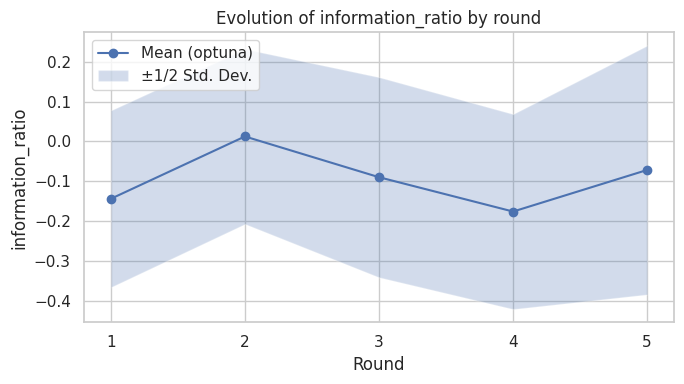

,run_id,round,information_ratio
0,20260129_183158,1,-0.776955
1,20260129_183941,1,-1.109860
2,20260129_185221,1,-0.514828
3,20260129_191343,1,-1.134011
15,20260130_141853,1,-0.104748
10,20260129_201801,1,-0.322511
29,20260202_061256,1,-0.272442
28,20260202_010919,1,-0.568662
24,20260201_122716,1,0.046833
25,20260201_130021,1,-0.251508


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# IC 대체로 가장 무난한 건 (OOS) excess_return_with_cost의 information_ratio 입니다.
# - IC처럼 scale-free (risk-adjusted)라서 round 간 비교가 쉽고
# - transaction cost를 포함할 수 있어 실제 운용 관점에 더 가깝습니다.

METRIC = "information_ratio"  # 예: annualized_return, net_return, max_drawdown
MODE = "optuna"              # optuna / fixed_q90 / fixed_q95 / None(전체)
GROUP_COL = None             # 예: "hypothesis_id" 또는 사용자 정의 그룹 컬럼

df_plot = df.copy()
if MODE is not None:
    df_plot = df_plot[df_plot["mode"] == MODE]

# outer_iter_1..N 에서 N만 뽑아 Round로 사용
df_plot["round"] = pd.to_numeric(
    df_plot["outer_iter"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)
print('rows after MODE filter:', len(df_plot))
if len(df_plot) > 0:
    print('mode counts (top):', df_plot['mode'].value_counts().head(5).to_dict())
    print('outer_iter sample:', df_plot['outer_iter'].astype(str).dropna().unique()[:5])
df_plot = df_plot.dropna(subset=["round", METRIC]).copy()
print(f'rows after dropna(round,{METRIC}):', len(df_plot))
df_plot["round"] = df_plot["round"].astype(int)

# round별로 여러 combo가 있으면, run(및 group) 단위에서 best(metric 최대)로 대표값을 잡는 게 보통 제일 직관적
keys = ["run_id", "round"]
if GROUP_COL is not None:
    keys = [GROUP_COL, *keys]

df_best = df_plot.groupby(keys, as_index=False)[METRIC].max()
if df_best.empty:
    print('df_best is empty -> 대부분 round 추출 실패 or metric이 전부 NaN 입니다.')
    print('확인 1) outer_iter에서 숫자 뽑는 정규식은 str.extract(r"(\\d+)") 처럼 \\d(한 번) 패턴이어야 합니다.')
    print('확인 2) MODE 값:', MODE, ' / df_plot.mode unique(top):', df_plot['mode'].value_counts().head(10).to_dict() if 'mode' in df_plot else None)
    print('확인 3) METRIC 값:', METRIC, ' / non-null:', int(df_plot[METRIC].notna().sum()) if METRIC in df_plot else None)
    cols = [c for c in ['run_id','outer_iter','round','mode',METRIC] if c in df_plot.columns]
    print(df_plot[cols].head(20).to_string(index=False))
    raise ValueError('df_best is empty (see debug prints above)')

plt.figure(figsize=(7, 4))

if GROUP_COL is None:
    agg = df_best.groupby("round")[METRIC].agg(["mean", "std", "count"]).reset_index()
    half_std = 0.5 * agg["std"].fillna(0.0)
    plt.plot(agg["round"], agg["mean"], marker="o", label=f"Mean ({MODE})")
    plt.fill_between(
        agg["round"],
        agg["mean"] - half_std,
        agg["mean"] + half_std,
        alpha=0.25,
        label="±1/2 Std. Dev.",
    )
else:
    for group_value, sub in df_best.groupby(GROUP_COL):
        agg = sub.groupby("round")[METRIC].agg(["mean", "std", "count"]).reset_index()
        half_std = 0.5 * agg["std"].fillna(0.0)
        plt.plot(agg["round"], agg["mean"], marker="o", label=f"{group_value} Mean")
        plt.fill_between(
            agg["round"],
            agg["mean"] - half_std,
            agg["mean"] + half_std,
            alpha=0.18,
        )

plt.xticks(sorted(df_best["round"].unique()))
plt.xlabel("Round")
plt.ylabel(METRIC)
plt.title(f"Evolution of {METRIC} by round")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 참고용 테이블
df_best.sort_values([*([] if GROUP_COL is None else [GROUP_COL]), "round"]).head(20)


rows after MODE filter: 2993
mode counts (top): {'optuna': 2993}
outer_iter sample: ['outer_iter_4' 'outer_iter_1' 'outer_iter_5' 'outer_iter_2'
 'outer_iter_3']
rows after dropna(round,information_ratio): 2632


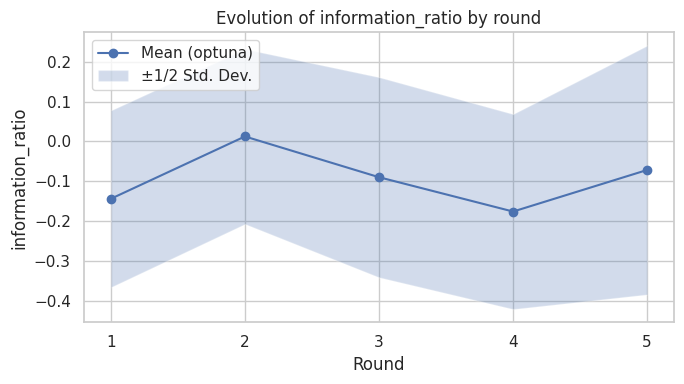

,run_id,round,information_ratio
0,20260129_183158,1,-0.776955
1,20260129_183941,1,-1.109860
2,20260129_185221,1,-0.514828
3,20260129_191343,1,-1.134011
15,20260130_141853,1,-0.104748
10,20260129_201801,1,-0.322511
29,20260202_061256,1,-0.272442
28,20260202_010919,1,-0.568662
24,20260201_122716,1,0.046833
25,20260201_130021,1,-0.251508


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# IC 대체로 가장 무난한 건 (OOS) excess_return_with_cost의 information_ratio 입니다.
# - IC처럼 scale-free (risk-adjusted)라서 round 간 비교가 쉽고
# - transaction cost를 포함할 수 있어 실제 운용 관점에 더 가깝습니다.

METRIC = "information_ratio"  # 예: annualized_return, net_return, max_drawdown
MODE = "optuna"              # optuna / fixed_q90 / fixed_q95 / None(전체)
GROUP_COL = None             # 예: "hypothesis_id" 또는 사용자 정의 그룹 컬럼

df_plot = df.copy()
if MODE is not None:
    df_plot = df_plot[df_plot["mode"] == MODE]

# outer_iter_1..N 에서 N만 뽑아 Round로 사용
df_plot["round"] = pd.to_numeric(
    df_plot["outer_iter"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)
print('rows after MODE filter:', len(df_plot))
if len(df_plot) > 0:
    print('mode counts (top):', df_plot['mode'].value_counts().head(5).to_dict())
    print('outer_iter sample:', df_plot['outer_iter'].astype(str).dropna().unique()[:5])
df_plot = df_plot.dropna(subset=["round", METRIC]).copy()
print(f'rows after dropna(round,{METRIC}):', len(df_plot))
df_plot["round"] = df_plot["round"].astype(int)

# round별로 여러 combo가 있으면, run(및 group) 단위에서 best(metric 최대)로 대표값을 잡는 게 보통 제일 직관적
keys = ["run_id", "round"]
if GROUP_COL is not None:
    keys = [GROUP_COL, *keys]

df_best = df_plot.groupby(keys, as_index=False)[METRIC].max()
if df_best.empty:
    print('df_best is empty -> 대부분 round 추출 실패 or metric이 전부 NaN 입니다.')
    print('확인 1) outer_iter에서 숫자 뽑는 정규식은 str.extract(r"(\\d+)") 처럼 \\d(한 번) 패턴이어야 합니다.')
    print('확인 2) MODE 값:', MODE, ' / df_plot.mode unique(top):', df_plot['mode'].value_counts().head(10).to_dict() if 'mode' in df_plot else None)
    print('확인 3) METRIC 값:', METRIC, ' / non-null:', int(df_plot[METRIC].notna().sum()) if METRIC in df_plot else None)
    cols = [c for c in ['run_id','outer_iter','round','mode',METRIC] if c in df_plot.columns]
    print(df_plot[cols].head(20).to_string(index=False))
    raise ValueError('df_best is empty (see debug prints above)')

plt.figure(figsize=(7, 4))

if GROUP_COL is None:
    agg = df_best.groupby("round")[METRIC].agg(["mean", "std", "count"]).reset_index()
    half_std = 0.5 * agg["std"].fillna(0.0)
    plt.plot(agg["round"], agg["mean"], marker="o", label=f"Mean ({MODE})")
    plt.fill_between(
        agg["round"],
        agg["mean"] - half_std,
        agg["mean"] + half_std,
        alpha=0.25,
        label="±1/2 Std. Dev.",
    )
else:
    for group_value, sub in df_best.groupby(GROUP_COL):
        agg = sub.groupby("round")[METRIC].agg(["mean", "std", "count"]).reset_index()
        half_std = 0.5 * agg["std"].fillna(0.0)
        plt.plot(agg["round"], agg["mean"], marker="o", label=f"{group_value} Mean")
        plt.fill_between(
            agg["round"],
            agg["mean"] - half_std,
            agg["mean"] + half_std,
            alpha=0.18,
        )

plt.xticks(sorted(df_best["round"].unique()))
plt.xlabel("Round")
plt.ylabel(METRIC)
plt.title(f"Evolution of {METRIC} by round")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 참고용 테이블
df_best.sort_values([*([] if GROUP_COL is None else [GROUP_COL]), "round"]).head(20)


skip baseline: rounds mismatch base=[1, 2, 3] ours=[1, 2, 3, 4, 5]


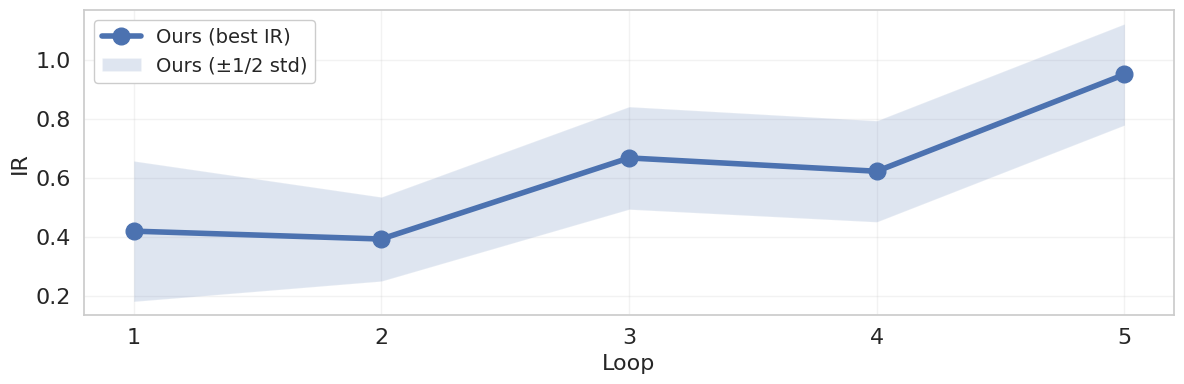

Ours:


,round,mean,std,count,max
0,1,-0.536874,0.475244,33,0.419702
1,2,-0.257517,0.284463,48,0.393039
2,3,-0.283746,0.347067,104,0.667401
3,4,-0.174194,0.342312,31,0.622314
4,5,-0.134288,0.342467,163,0.949681


In [25]:
# Legacy IR plot (ours + optional baselines)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

sns.set_theme(style="whitegrid")

# ------------------- settings -------------------
ONE_RUN = "20260206_142717"  # outer_iter_1~N 있는 run_id
METRIC = "information_ratio"  # 보통 IR을 보기 좋음
MODE = "optuna"               # optuna / fixed_q90 / fixed_q95

# 어떤 통계를 그릴지: mean / max
PLOT_STAT = "best"  # "mean" | "max" | "best" (higher of mean/max per round)
PLOT_RDAGENT = False
PLOT_ALPHAAGENT = False

# R&D-Agent / AlphaForge : metrics_timeseries.csv 기반 loop별 IR 재계산
RDAGENT_METRICS_TS = Path("/home/dgu/fin/01_15_new_qlib copy/metrics_timeseries.csv")
AUTO_SELECT_BASELINE_FILES = True
MIN_BASELINE_ROUNDS = 5

# AlphaAgent : AlphaAgent/log/*/metrics.csv 기반 loop별 IR
# - 지정 안 하면 가장 최신 metrics.csv를 자동 선택
ALPHAAGENT_METRICS_CSV = None

# baseline loop index를 1부터 보이게 정규화할지
NORMALIZE_BASELINE_LOOP_TO_1 = True
REQUIRE_BASELINE_FULL_LOOPS = True  # ours rounds와 동일 개수/셋일 때만 baseline 표시

TRADING_DAYS = 252

# save options
SAVE_PDF = True
PDF_PATH = Path("/home/dgu/fin/01_15_new_qlib/analysis/ir_plot.pdf")


def _annualized_ir(daily_excess: pd.Series, trading_days: int = 252) -> float:
    daily_excess = daily_excess.astype(float).dropna()
    if len(daily_excess) == 0:
        return float("nan")
    mean = float(daily_excess.mean())
    std = float(daily_excess.std(ddof=0))
    if std <= 0:
        return float("nan")
    return float(mean / std * (trading_days ** 0.5))


def _count_rounds_from_metrics_ts(p: Path) -> int:
    try:
        df = pd.read_csv(p, usecols=["loop"])
        return int(df["loop"].nunique())
    except Exception:
        return 0


def _count_rounds_from_alphaagent_metrics(p: Path) -> int:
    try:
        df = pd.read_csv(p, usecols=["loop"])
        return int(df["loop"].nunique())
    except Exception:
        return 0


def _latest_metrics_timeseries_csv(min_rounds: int = 5) -> Path | None:
    # search common locations for metrics_timeseries.csv
    cands = []
    roots = [
        Path("/home/dgu/fin/01_15_new_qlib copy"),
        Path("/home/dgu/fin/others/02_agent/AlphaForge"),
    ]
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("metrics_timeseries.csv"):
            n = _count_rounds_from_metrics_ts(p)
            if n >= min_rounds:
                cands.append((p.stat().st_mtime, p))
    if not cands:
        return None
    cands.sort(reverse=True)
    return cands[0][1]


def _load_rdagent_loop_metrics(ts_path: Path) -> pd.DataFrame:
    df_ts = pd.read_csv(ts_path)
    df_ts["date"] = pd.to_datetime(df_ts["date"])
    df_ts = df_ts.sort_values(["loop", "date"]).copy()

    cum_col = "Cumulative Excess Return (With Cost)"
    if cum_col not in df_ts.columns:
        raise ValueError(f"missing column: {cum_col} in {ts_path}")

    rows = []
    for loop, g in df_ts.groupby("loop"):
        g = g.sort_values("date")
        cum = g[cum_col].astype(float)
        daily = cum.diff().fillna(cum.iloc[0])
        rows.append(
            {
                "loop": int(loop),
                "IR": _annualized_ir(daily, TRADING_DAYS),
                "CR_excess_end": float(cum.iloc[-1]),
                "end_date": g["date"].iloc[-1].date().isoformat(),
            }
        )

    out = pd.DataFrame(rows).sort_values("loop")
    return out


def _latest_alphaagent_metrics_csv(min_rounds: int = 5) -> Path | None:
    root = Path("/home/dgu/fin/AlphaAgent/log")
    if not root.exists():
        return None
    cands = []
    for p in root.glob("*/metrics.csv"):
        n = _count_rounds_from_alphaagent_metrics(p)
        if n >= min_rounds:
            cands.append((p.stat().st_mtime, p))
    if not cands:
        return None
    cands.sort(reverse=True)
    return cands[0][1]


def _load_alphaagent_loop_metrics(metrics_csv: Path) -> pd.DataFrame:
    df_m = pd.read_csv(metrics_csv)
    if "section" in df_m.columns:
        df_m = df_m[df_m["section"] == "with_cost"].copy()

    # loop별로 마지막(최신) row를 사용
    df_m = df_m.sort_values(["loop", "timestamp"]).copy()
    last = df_m.groupby("loop", as_index=False).tail(1)

    out = last[["loop", "Information Ratio", "Cumulative Return", "Max Drawdown", "timestamp"]].copy()
    out = out.rename(
        columns={
            "Information Ratio": "IR",
            "Cumulative Return": "CR_end",
            "Max Drawdown": "MDD",
            "timestamp": "ts",
        }
    )
    out["loop"] = out["loop"].astype(int)
    return out.sort_values("loop")


def _norm_loop(loop_s: pd.Series) -> pd.Series:
    loop_s = loop_s.astype(int)
    if not NORMALIZE_BASELINE_LOOP_TO_1:
        return loop_s
    return loop_s - int(loop_s.min()) + 1


def _maybe_filter_baseline(df_base: pd.DataFrame | None, ours_rounds: list[int]) -> pd.DataFrame | None:
    if df_base is None or len(df_base) == 0:
        return df_base
    if not REQUIRE_BASELINE_FULL_LOOPS:
        return df_base
    base_rounds = sorted(set(int(x) for x in _norm_loop(df_base["loop"]).unique()))
    ours_rounds = sorted(set(int(x) for x in ours_rounds))
    if base_rounds != ours_rounds:
        print(f"skip baseline: rounds mismatch base={base_rounds} ours={ours_rounds}")
        return None
    return df_base


# ------------------- ours: round별 IR -------------------
df_run = df[(df["run_id"] == ONE_RUN) & (df["mode"] == MODE)].copy()
df_run["round"] = pd.to_numeric(
    df_run["outer_iter"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)
df_run = df_run.dropna(subset=["round", METRIC]).copy()
df_run["round"] = df_run["round"].astype(int)

if df_run.empty:
    raise ValueError(f"No rows for run_id={ONE_RUN}, mode={MODE}, metric={METRIC}")

agg = (
    df_run.groupby("round")[METRIC]
    .agg(["mean", "std", "count", "max"])
    .reset_index()
    .sort_values("round")
)

half_std = 0.5 * agg["std"].fillna(0.0)

# ------------------- baselines: loop별 IR -------------------
rd_tbl = None
rd_csv = RDAGENT_METRICS_TS
if AUTO_SELECT_BASELINE_FILES:
    rd_csv = _latest_metrics_timeseries_csv(MIN_BASELINE_ROUNDS) or RDAGENT_METRICS_TS
if rd_csv is not None and Path(rd_csv).exists():
    rd_tbl = _load_rdagent_loop_metrics(Path(rd_csv))

alphaagent_csv = ALPHAAGENT_METRICS_CSV
if AUTO_SELECT_BASELINE_FILES:
    alphaagent_csv = _latest_alphaagent_metrics_csv(MIN_BASELINE_ROUNDS) or alphaagent_csv
elif alphaagent_csv is None:
    alphaagent_csv = _latest_alphaagent_metrics_csv(MIN_BASELINE_ROUNDS)

aa_tbl = None
if alphaagent_csv is not None and Path(alphaagent_csv).exists():
    aa_tbl = _load_alphaagent_loop_metrics(Path(alphaagent_csv))

# baseline loop count check
ours_rounds = list(agg["round"])
rd_tbl = _maybe_filter_baseline(rd_tbl, ours_rounds)
aa_tbl = _maybe_filter_baseline(aa_tbl, ours_rounds)


# ------------------- plot -------------------
plt.figure(figsize=(12, 4))

if PLOT_STAT == "mean":
    y = agg["mean"]
    label = "Ours (mean IR)"
elif PLOT_STAT == "max":
    y = agg["max"]
    label = "Ours (max IR)"
elif PLOT_STAT == "best":
    y = np.maximum(agg["mean"], agg["max"])
    label = "Ours (best IR)"
else:
    raise ValueError(f"Unknown PLOT_STAT: {PLOT_STAT}")

plt.plot(
    agg["round"],
    y,
    marker="o",
    markersize=12,
    linewidth=4,
    label=label,
)

plt.fill_between(
    agg["round"],
    y - half_std,
    y + half_std,
    alpha=0.18,
    label="Ours (±1/2 std)",
)

if PLOT_RDAGENT and rd_tbl is not None and len(rd_tbl) > 0:
    x = _norm_loop(rd_tbl["loop"])
    plt.plot(x, rd_tbl["IR"], marker="s", markersize=7, linewidth=3, label="R&D-Agent/AlphaForge (IR)")

if PLOT_ALPHAAGENT and aa_tbl is not None and len(aa_tbl) > 0:
    x = _norm_loop(aa_tbl["loop"])
    plt.plot(x, aa_tbl["IR"], marker="^", markersize=7, linewidth=3, label="AlphaAgent (IR)")

plt.xlabel("Loop", fontsize=16)
plt.ylabel("IR", fontsize=16)
plt.tick_params(axis="both", which="major", labelsize=16)

plt.xticks(sorted(set(int(x) for x in agg["round"].unique())))
plt.grid(True, alpha=0.25)
plt.legend(
    loc="best",
    fontsize=14,
    frameon=True,        # 박스 ON
    facecolor="white",   # 흰 배경
    framealpha=1.0       # 완전 불투명
)

plt.tight_layout()
if SAVE_PDF:
    PDF_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(PDF_PATH, format="pdf", bbox_inches="tight")
plt.show()

# ------------------- tables -------------------
print('Ours:')
display(agg)

if PLOT_RDAGENT and rd_tbl is not None:
    print('R&D-Agent/AlphaForge (from metrics_timeseries.csv):')
    display(rd_tbl)

if PLOT_ALPHAAGENT and aa_tbl is not None:
    print(f'AlphaAgent (from {alphaagent_csv}):')
    display(aa_tbl)


<>:253: SyntaxWarning: invalid escape sequence '\p'
<>:253: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_545241/1236977223.py:253: SyntaxWarning: invalid escape sequence '\p'
  label="Confidence Interval ($\pm 0.5$ std)",


skip baseline: rounds mismatch base=[1, 2, 3] ours=[1, 2, 3, 4, 5]
✨ 화보급 PDF 저장 완료: /home/dgu/fin/01_15_new_qlib/analysis/ir_plot.pdf


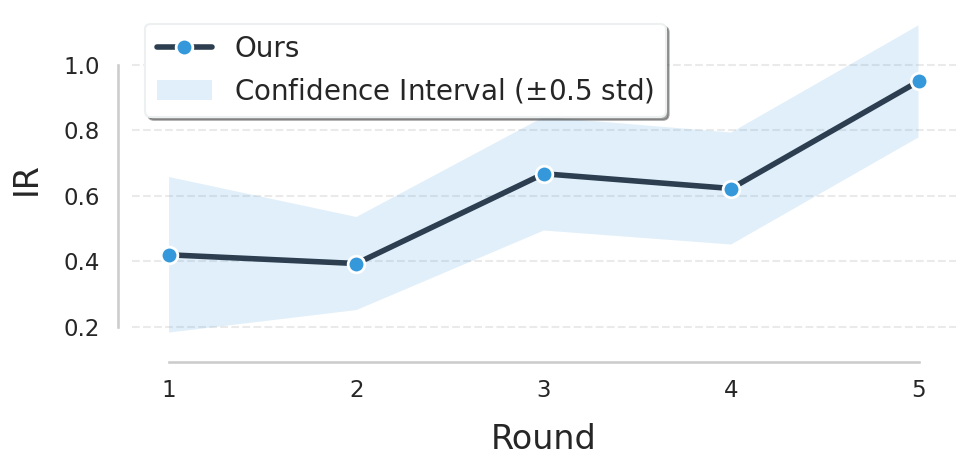

Ours:


,round,mean,std,count,max
0,1,-0.536874,0.475244,33,0.419702
1,2,-0.257517,0.284463,48,0.393039
2,3,-0.283746,0.347067,104,0.667401
3,4,-0.174194,0.342312,31,0.622314
4,5,-0.134288,0.342467,163,0.949681


In [26]:
# Legacy IR plot (ours + optional baselines)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
from pathlib import Path

sns.set_theme(style="whitegrid")

# ------------------- settings -------------------
ONE_RUN = "20260206_142717"  # outer_iter_1~N 있는 run_id        ####여기바꾸면됨################################################################################################
METRIC = "information_ratio"  # 보통 IR을 보기 좋음
MODE = "optuna"               # optuna / fixed_q90 / fixed_q95

# 어떤 통계를 그릴지: mean / max
PLOT_STAT = "best"  # "mean" | "max" | "best" (higher of mean/max per round)
PLOT_RDAGENT = False
PLOT_ALPHAAGENT = False

# R&D-Agent / AlphaForge : metrics_timeseries.csv 기반 loop별 IR 재계산
RDAGENT_METRICS_TS = Path("/home/dgu/fin/01_15_new_qlib copy/metrics_timeseries.csv")
AUTO_SELECT_BASELINE_FILES = True
MIN_BASELINE_ROUNDS = 5

# AlphaAgent : AlphaAgent/log/*/metrics.csv 기반 loop별 IR
# - 지정 안 하면 가장 최신 metrics.csv를 자동 선택
ALPHAAGENT_METRICS_CSV = None

# baseline loop index를 1부터 보이게 정규화할지
NORMALIZE_BASELINE_LOOP_TO_1 = True
REQUIRE_BASELINE_FULL_LOOPS = True  # ours rounds와 동일 개수/셋일 때만 baseline 표시

TRADING_DAYS = 252

# save options
SAVE_PDF = True
PDF_PATH = Path("/home/dgu/fin/01_15_new_qlib/analysis/ir_plot.pdf")


def _annualized_ir(daily_excess: pd.Series, trading_days: int = 252) -> float:
    daily_excess = daily_excess.astype(float).dropna()
    if len(daily_excess) == 0:
        return float("nan")
    mean = float(daily_excess.mean())
    std = float(daily_excess.std(ddof=0))
    if std <= 0:
        return float("nan")
    return float(mean / std * (trading_days ** 0.5))


def _count_rounds_from_metrics_ts(p: Path) -> int:
    try:
        df = pd.read_csv(p, usecols=["loop"])
        return int(df["loop"].nunique())
    except Exception:
        return 0


def _count_rounds_from_alphaagent_metrics(p: Path) -> int:
    try:
        df = pd.read_csv(p, usecols=["loop"])
        return int(df["loop"].nunique())
    except Exception:
        return 0


def _latest_metrics_timeseries_csv(min_rounds: int = 5) -> Path | None:
    # search common locations for metrics_timeseries.csv
    cands = []
    roots = [
        Path("/home/dgu/fin/01_15_new_qlib copy"),
        Path("/home/dgu/fin/others/02_agent/AlphaForge"),
    ]
    for root in roots:
        if not root.exists():
            continue
        for p in root.rglob("metrics_timeseries.csv"):
            n = _count_rounds_from_metrics_ts(p)
            if n >= min_rounds:
                cands.append((p.stat().st_mtime, p))
    if not cands:
        return None
    cands.sort(reverse=True)
    return cands[0][1]


def _load_rdagent_loop_metrics(ts_path: Path) -> pd.DataFrame:
    df_ts = pd.read_csv(ts_path)
    df_ts["date"] = pd.to_datetime(df_ts["date"])
    df_ts = df_ts.sort_values(["loop", "date"]).copy()

    cum_col = "Cumulative Excess Return (With Cost)"
    if cum_col not in df_ts.columns:
        raise ValueError(f"missing column: {cum_col} in {ts_path}")

    rows = []
    for loop, g in df_ts.groupby("loop"):
        g = g.sort_values("date")
        cum = g[cum_col].astype(float)
        daily = cum.diff().fillna(cum.iloc[0])
        rows.append(
            {
                "loop": int(loop),
                "IR": _annualized_ir(daily, TRADING_DAYS),
                "CR_excess_end": float(cum.iloc[-1]),
                "end_date": g["date"].iloc[-1].date().isoformat(),
            }
        )

    out = pd.DataFrame(rows).sort_values("loop")
    return out


def _latest_alphaagent_metrics_csv(min_rounds: int = 5) -> Path | None:
    root = Path("/home/dgu/fin/AlphaAgent/log")
    if not root.exists():
        return None
    cands = []
    for p in root.glob("*/metrics.csv"):
        n = _count_rounds_from_alphaagent_metrics(p)
        if n >= min_rounds:
            cands.append((p.stat().st_mtime, p))
    if not cands:
        return None
    cands.sort(reverse=True)
    return cands[0][1]


def _load_alphaagent_loop_metrics(metrics_csv: Path) -> pd.DataFrame:
    df_m = pd.read_csv(metrics_csv)
    if "section" in df_m.columns:
        df_m = df_m[df_m["section"] == "with_cost"].copy()

    # loop별로 마지막(최신) row를 사용
    df_m = df_m.sort_values(["loop", "timestamp"]).copy()
    last = df_m.groupby("loop", as_index=False).tail(1)

    out = last[["loop", "Information Ratio", "Cumulative Return", "Max Drawdown", "timestamp"]].copy()
    out = out.rename(
        columns={
            "Information Ratio": "IR",
            "Cumulative Return": "CR_end",
            "Max Drawdown": "MDD",
            "timestamp": "ts",
        }
    )
    out["loop"] = out["loop"].astype(int)
    return out.sort_values("loop")


def _norm_loop(loop_s: pd.Series) -> pd.Series:
    loop_s = loop_s.astype(int)
    if not NORMALIZE_BASELINE_LOOP_TO_1:
        return loop_s
    return loop_s - int(loop_s.min()) + 1


def _maybe_filter_baseline(df_base: pd.DataFrame | None, ours_rounds: list[int]) -> pd.DataFrame | None:
    if df_base is None or len(df_base) == 0:
        return df_base
    if not REQUIRE_BASELINE_FULL_LOOPS:
        return df_base
    base_rounds = sorted(set(int(x) for x in _norm_loop(df_base["loop"]).unique()))
    ours_rounds = sorted(set(int(x) for x in ours_rounds))
    if base_rounds != ours_rounds:
        print(f"skip baseline: rounds mismatch base={base_rounds} ours={ours_rounds}")
        return None
    return df_base


# ------------------- ours: round별 IR -------------------
df_run = df[(df["run_id"] == ONE_RUN) & (df["mode"] == MODE)].copy()
df_run["round"] = pd.to_numeric(
    df_run["outer_iter"].astype(str).str.extract(r"(\d+)")[0],
    errors="coerce",
)
df_run = df_run.dropna(subset=["round", METRIC]).copy()
df_run["round"] = df_run["round"].astype(int)

if df_run.empty:
    raise ValueError(f"No rows for run_id={ONE_RUN}, mode={MODE}, metric={METRIC}")

agg = (
    df_run.groupby("round")[METRIC]
    .agg(["mean", "std", "count", "max"])
    .reset_index()
    .sort_values("round")
)

half_std = 0.5 * agg["std"].fillna(0.0)

# ------------------- baselines: loop별 IR -------------------
rd_tbl = None
rd_csv = RDAGENT_METRICS_TS
if AUTO_SELECT_BASELINE_FILES:
    rd_csv = _latest_metrics_timeseries_csv(MIN_BASELINE_ROUNDS) or RDAGENT_METRICS_TS
if rd_csv is not None and Path(rd_csv).exists():
    rd_tbl = _load_rdagent_loop_metrics(Path(rd_csv))

alphaagent_csv = ALPHAAGENT_METRICS_CSV
if AUTO_SELECT_BASELINE_FILES:
    alphaagent_csv = _latest_alphaagent_metrics_csv(MIN_BASELINE_ROUNDS) or alphaagent_csv
elif alphaagent_csv is None:
    alphaagent_csv = _latest_alphaagent_metrics_csv(MIN_BASELINE_ROUNDS)

aa_tbl = None
if alphaagent_csv is not None and Path(alphaagent_csv).exists():
    aa_tbl = _load_alphaagent_loop_metrics(Path(alphaagent_csv))

# baseline loop count check
ours_rounds = list(agg["round"])
rd_tbl = _maybe_filter_baseline(rd_tbl, ours_rounds)
aa_tbl = _maybe_filter_baseline(aa_tbl, ours_rounds)


# ------------------- plot -------------------
# ------------------- Improved Professional Plot -------------------
plt.figure(figsize=(10, 5))  # 가로 길이를 조금 늘려 여유를 줌

# 스타일 세부 설정
sns.set_context("talk") # 전체적인 요소 크기 확대
plt.rcParams['font.family'] = 'sans-serif' # 깔끔한 폰트 설정

# 통계값 선택
if PLOT_STAT == "mean":
    y = agg["mean"]
    label = "Ours (Mean IR)"
elif PLOT_STAT == "max":
    y = agg["max"]
    label = "Ours (Max IR)"
elif PLOT_STAT == "best":
    y = np.maximum(agg["mean"], agg["max"])
    label = "Ours"

# 1. 메인 라인 플롯 (그림자 효과와 두께 조절)
line, = plt.plot(
    agg["round"], y,
    marker="o", markersize=12,
    linewidth=4, color="#2c3e50", # Deep Navy
    markerfacecolor="#3498db",    # Bright Blue
    markeredgewidth=2, markeredgecolor="white",
    label=label, zorder=3
)

# 2. 표준편차 영역 (부드러운 색감)
plt.fill_between(
    agg["round"],
    y - half_std,
    y + half_std,
    alpha=0.15,
    color="#3498db",
    label="Confidence Interval ($\pm 0.5$ std)",
    edgecolor="none",
    zorder=2
)

# 3. Baseline (표시될 경우) - 세련된 점선/색상
if PLOT_RDAGENT and rd_tbl is not None and len(rd_tbl) > 0:
    plt.plot(_norm_loop(rd_tbl["loop"]), rd_tbl["IR"], 
             linestyle='--', marker="s", markersize=8, color="#e67e22", label="R&D-Agent")

if PLOT_ALPHAAGENT and aa_tbl is not None and len(aa_tbl) > 0:
    plt.plot(_norm_loop(aa_tbl["loop"]), aa_tbl["IR"], 
             linestyle='--', marker="^", markersize=8, color="#27ae60", label="AlphaAgent")

# 4. 축 및 그리드 정리
plt.xlabel("Round", fontsize=24, labelpad=15)
plt.ylabel("IR", fontsize=24, labelpad=15)
plt.xticks(sorted(set(int(x) for x in agg["round"].unique())), fontsize=20)
plt.yticks(fontsize=20)

# 그리드를 연하게 설정하여 데이터 방해 금지
plt.grid(True, axis='y', linestyle='--', alpha=0.4, zorder=1)
plt.grid(False, axis='x') # x축 그리드는 제거해서 더 깔끔하게

# 테두리 제거 (Top, Right)
sns.despine(trim=True, offset=10)

# 5. 레전드 꾸미기
plt.legend(
    loc="upper left", 
    fontsize=20, 
    frameon=True, 
    fancybox=True, 
    shadow=True, 
    facecolor="white", 
    edgecolor="#ecf0f1"
)

# 수치 데이터 텍스트 표시 (선택 사항: 최고점 강조)
# max_idx = y.idxmax()
# plt.annotate(f'Peak: {y.max():.2f}', 
#              xy=(agg["round"].iloc[max_idx], y.max()), 
#              xytext=(10, 10), textcoords='offset points',
#              fontsize=14, fontweight='bold', color="#c0392b")

plt.tight_layout()

# PDF 저장
if SAVE_PDF:
    PDF_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(PDF_PATH, format="pdf", bbox_inches="tight", transparent=True)
    print(f"✨ 화보급 PDF 저장 완료: {PDF_PATH}")

plt.show()

# ------------------- tables -------------------
print('Ours:')
display(agg)

if PLOT_RDAGENT and rd_tbl is not None:
    print('R&D-Agent/AlphaForge (from metrics_timeseries.csv):')
    display(rd_tbl)

if PLOT_ALPHAAGENT and aa_tbl is not None:
    print(f'AlphaAgent (from {alphaagent_csv}):')
    display(aa_tbl)


PDF 저장 완료: /home/dgu/fin/01_15_new_qlib/analysis/ir_plot.pdf


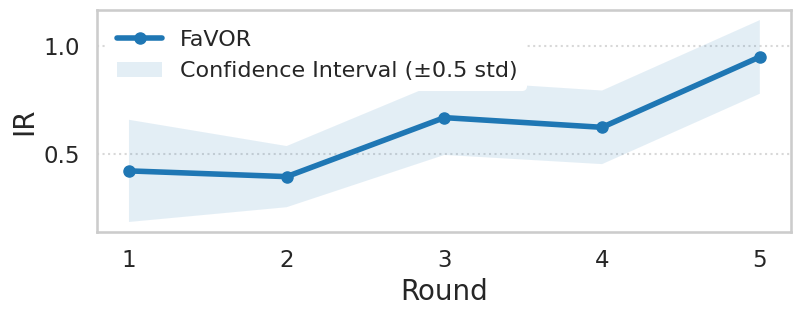

In [27]:
# ------------------- plot (simple & clean) -------------------
plt.figure(figsize=(8.5, 3.5))
plt.rcParams['font.family'] = 'sans-serif'

# 통계값 선택
if PLOT_STAT == "mean":
    y = agg["mean"]
    label = "Ours (Mean IR)"
elif PLOT_STAT == "max":
    y = agg["max"]
    label = "Ours (Max IR)"
elif PLOT_STAT == "best":
    y = np.maximum(agg["mean"], agg["max"])
    label = "Ours"

# main line
plt.plot(
    agg["round"], y,
    marker="o", markersize=8,
    linewidth=4,  # 더 두껍게
    color="#1f77b4",
    label="FaVOR"
)

# light std band
plt.fill_between(
    agg["round"],
    y - half_std,
    y + half_std,
    alpha=0.12,
    color="#1f77b4",
    edgecolor="none",
    label="Confidence Interval (±0.5 std)"
)
# baselines (subtle dashed)
if PLOT_RDAGENT and rd_tbl is not None and len(rd_tbl) > 0:
    plt.plot(_norm_loop(rd_tbl["loop"]), rd_tbl["IR"],
             linestyle='--', linewidth=2, color="#ff7f0e", label="R&D-Agent")

if PLOT_ALPHAAGENT and aa_tbl is not None and len(aa_tbl) > 0:
    plt.plot(_norm_loop(aa_tbl["loop"]), aa_tbl["IR"],
             linestyle='--', linewidth=2, color="#2ca02c", label="AlphaAgent")

# axes/grid
plt.xlabel("Round", fontsize=20)
plt.ylabel("IR", fontsize=20)
plt.xticks(sorted(set(int(x) for x in agg["round"].unique())))
plt.grid(True, axis='y', linestyle=':', alpha=0.75)
plt.grid(False, axis='x')

plt.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0,
    fontsize=16,
)

plt.tight_layout()

# PDF 저장
if SAVE_PDF:
    PDF_PATH.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(PDF_PATH, format="pdf", bbox_inches="tight")
    print(f"PDF 저장 완료: {PDF_PATH}")

plt.show()


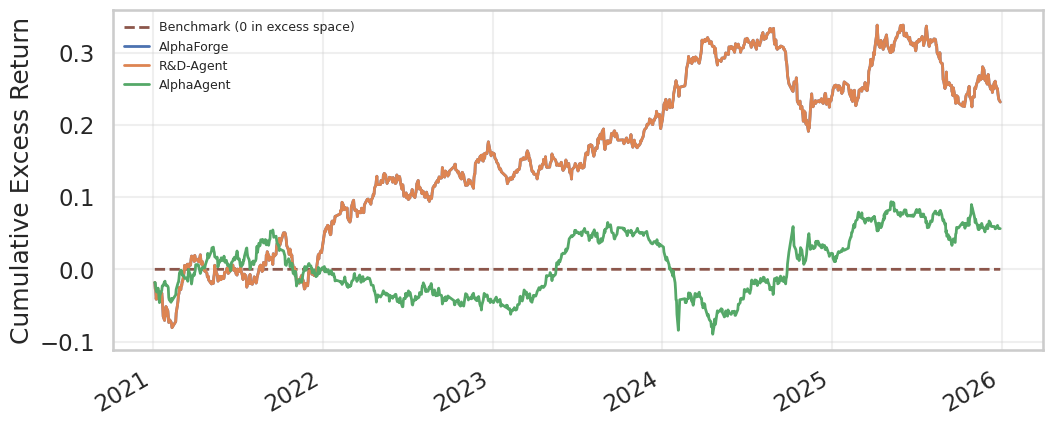

,last_date,end_value
AlphaForge,2025-12-29,0.231744
R&D-Agent,2025-12-29,0.231744
AlphaAgent,2025-12-26,0.056409


In [28]:
# Multi-line cumulative excess return plot (AlphaForge / R&D-Agent / AlphaAgent)

from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def _safe_read_pickle(p):
    """pd.read_pickle wrapper that tolerates NumPy 2.x pickles (numpy._core) in NumPy 1.x envs."""
    try:
        return pd.read_pickle(p)
    except ModuleNotFoundError as e:
        if "numpy._core" not in str(e):
            raise
        import numpy.core as npcore

        sys.modules.setdefault("numpy._core", npcore)
        try:
            import numpy.core._multiarray_umath as mau

            sys.modules.setdefault("numpy._core._multiarray_umath", mau)
        except Exception:
            pass
        return pd.read_pickle(p)


# --- project root 찾기 (run.cumulative_return import용) ---
CWD = Path.cwd().resolve()
if CWD.name == "analysis" and (CWD / "0203 copy 2.ipynb").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = None
    cur = CWD
    for _ in range(6):
        if (cur / "run").is_dir() and (cur / "runs").is_dir():
            PROJECT_ROOT = cur
            break
        cur = cur.parent
    if PROJECT_ROOT is None:
        PROJECT_ROOT = CWD

sys.path.insert(0, str(PROJECT_ROOT))
from run.cumulative_return import _compute_curves  # noqa: E402


PLOT_KIND = "excess_with_cost"  # "excess_with_cost" | "excess_without_cost"
CUM_METHOD = "qlib_cumsum"      # "qlib_cumsum" | "compound"

LABEL_TO_PKL: dict[str, str] = {
    "AlphaForge": "/home/dgu/fin/01_15_new_qlib copy/2026-02-03_06-31-06-947364.pkl",
    "R&D-Agent": "/home/dgu/fin/01_15_new_qlib copy/2026-02-03_06-31-06-947364.pkl",
    "AlphaAgent": "/home/dgu/fin/AlphaAgent/results/2026-02-03_17-23-06-199838/backtest/1711570d9efb4e6191ec765dffc93c86/ret.pkl",
    "Ours": "/home/dgu/fin/01_15_new_qlib/runs/20260206_142717/qlib_artifacts/iter_4/combo_10/oos/report_normal_1day.pkl",
}

# 원하는 라벨만 선택해서 그리기
PLOT_LABELS = ["AlphaForge", "R&D-Agent", "AlphaAgent"]  # + ["Ours"]
label_to_pkl = {k: v for k, v in LABEL_TO_PKL.items() if k in set(PLOT_LABELS)}
if not label_to_pkl:
    raise ValueError("No labels selected. Check PLOT_LABELS / LABEL_TO_PKL")


def _daily_excess_series_from_pkl(pkl_path: str, plot_kind: str) -> pd.Series:
    df = _safe_read_pickle(pkl_path)
    curves = _compute_curves(df)

    bench = curves["bench"] if "bench" in curves.columns else 0.0

    if plot_kind == "excess_with_cost":
        daily = curves["net"] - bench
    elif plot_kind == "excess_without_cost":
        daily = curves["gross"] - bench
    else:
        raise ValueError(f"Unknown plot_kind: {plot_kind}")

    daily = daily.astype(float).fillna(0.0)
    daily.name = Path(pkl_path).parent.name
    return daily


def _cumulate(daily: pd.Series, method: str) -> pd.Series:
    if method == "qlib_cumsum":
        return daily.cumsum()
    if method == "compound":
        return (1.0 + daily).cumprod() - 1.0
    raise ValueError(f"Unknown method: {method}")


series = {
    label: _cumulate(_daily_excess_series_from_pkl(pkl_path, PLOT_KIND), CUM_METHOD)
    for label, pkl_path in label_to_pkl.items()
}

curve_df_raw = pd.concat(series, axis=1).sort_index()
curve_df = curve_df_raw.ffill()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(curve_df.index, [0.0] * len(curve_df), "--", color="#8c564b", linewidth=2, label="Benchmark (0 in excess space)")
for col in curve_df.columns:
    ax.plot(curve_df.index, curve_df[col], linewidth=2, label=col)

ax.set_ylabel("Cumulative Excess Return")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9, frameon=False)
fig.autofmt_xdate()
plt.show()


# end-point table (각 라인별 마지막 유효값 기준)
last_valid = curve_df_raw.apply(lambda s: s.dropna().iloc[-1] if s.notna().any() else float("nan"))
last_date = curve_df_raw.apply(lambda s: s.dropna().index[-1].date().isoformat() if s.notna().any() else None)
end_table = (
    pd.DataFrame({"last_date": last_date, "end_value": last_valid})
    .sort_values("end_value", ascending=False)
)
end_table
